In [ ]:
!pip install formulaic

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 4.0 MB/s eta 0:00:00


In [ ]:
import seaborn as sns
from sklearn.model_selection import KFold
import matplotlib.pyplot as plt

from scipy import stats
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from formulaic import model_matrix

In [ ]:
#import os
#print(pwd)
#os.chdir('./notebooks')

En Python, las funciones y paquetes para trabajar con datos no están pensadas para poder hacerlas "sin saber nada de Python". Al contrario, muchas operaciones sencillas de DataFrames requieren conocer técnicas de programación en Python. Vamos a ver algunas en esta clase, principalmente estas:

## 1. Funciones lambda
## 2. Definición de listas por comprensión

**Ejercicio 1 (repaso).** En el dataset de vinos:
1. renombrar la columna "od280/od315_of_diluted_wines" a "od280_od315_of_diluted_wines".
2. pasar todos los nombres de columnas a mayúsculas

In [ ]:
from sklearn.datasets import load_wine
wine = load_wine(as_frame=True)
wineData = wine.data
wineData.head()

Hay esencialmente dos formas de renombrar columnas:
1. Utilizar rename()
2. Modificar la lista de nombres de columnas dataframe.columns

Comenzamos con rename().

In [ ]:
wineData.rename??

# O help(pd.DataFrame.rename)

Vemos que podemos renombrar columnas utilizando `columns: dict-like or function`

Para renombrar una columna, usamos rename(columns = _DICT_) y un diccionario con "nombre viejo" como claves y "nombre nuevo" como valores.

In [ ]:
wineData.rename(columns = {"od280/od315_of_diluted_wines" : "od280_od315_of_diluted_wines"})

También podemos usar funciones para renombrar columnas.

Para pasar todos los nombres de columnas a mayúsculas, usamos la función str.upper()

In [ ]:
wineData.rename(columns = str.upper)

Cuando no existe una función que hace exactamente lo que queremos, podemos definirla nosotros.

**Ejemplo:** Agregar a todos los nombres de columnas, el prefijo "orig_".

In [ ]:
def agregarPrefijo(s):
    return ("orig_" + s)

agregarPrefijo("edad")

In [ ]:
wineData.rename(columns = agregarPrefijo)

## 1. Funciones lambda
Resulta engorroso definir una función para usarla solamente dentro del rename.

Las funciones lambda nos permiten definir funciones anónimas "al vuelo".

La sintaxis es

lambda argumentos : expresion

In [ ]:
# Ejemplo
x = lambda a : a + 10
print(x(5))

**Nota:** `lambda` es una palabra de python, no es un nombre que elegimos nosotros para la función. Son funciones anónimas (que en este ejemplo la guardamos en la variable x)

In [ ]:
# Ejemplo
x = lambda a : a + 1
print(x(5))

In [ ]:
# Ejemplo (función con dos argumentos o parámetros)
x = lambda a, b : a * b
print(x(5, 6))

**Ejercicio:** Como podemos usar una función lambda sin asignarla primero a una variable?

In [ ]:
# Ahora hacemos el rename usando funciones lambda

In [ ]:
wineData.rename(columns = lambda x : "orig_" + x)

También podemos usar `rename` para modificar los índices.

**Ejercicio:**
En la base de datos de pingüinos,
1. Cambiar el índice 0 a "Cero".
2. Tomas la raíz cuadradada de los índices (del dataset original).

In [ ]:
penguins = sns.load_dataset("penguins")
penguins

In [ ]:
# Cambiamos el indice 0 a "Cero"


In [ ]:
# Tomamos raiz cuadradas de los índices
penguins.rename(index = np.sqrt)

In [ ]:
**Ejemplo:** Si queremos sumarle uno a todos los índices, ¿cómo podemos hacerlo?

In [ ]:
# Una posibilidad es modificar el array de índices
penguins.index = penguins.index + 1
penguins

In [ ]:
# O más brevemente
penguins.index += 1

¿Qué hacemos si queremos primero eliminar filas con datos faltantes, luego resetear los índices y luego sumarle uno a todos los índices?

¿Podemos encadenar esta última operación con las anteriores?

In [ ]:
# Para encadenar esa operación podemos usar rename y una función lambda!
penguins.rename(index = lambda a : a + 1)

Esta operación la podemos encadenar con las anteriores:

In [ ]:
penguinsClean = penguins.dropna().reset_index(drop = True).rename(index = lambda a : a + 1)
penguinsClean.head()

In [ ]:
# O si queremos cada metodo en una linea nueva
penguinsClean = (
    penguins.dropna()
    .reset_index(drop = True)
    .rename(index = lambda a : a + 1)
)
penguinsClean.head()

**Ejercicio:** Encadanar un método más para cambiar todos los _ por -.

## 2. Listas por comprensión

**Ejemplo:** Queremos cargar el siguiente dataset de variables de oferta y demanda nacional y generar un nuevo dataset que contenga sólo las variables de oferta (las que comienzan con "Oferta").

¿Cómo podemos hacerlo?



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
macro = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Lic_CsdeDatos/LaboDatos/OfertaYDemanda.csv")
macro.head()

,ano,pbi,OfertaAgricultura,OfertaMinas,OfertaManufacturera,OfertaElectricidad,OfertaConstruccion,OfertaComercio,OfertaTransporte,OfertaFinaciera,...,DemandaConsumoHogares,DemandaConsumoGobiertano,DemandaConstrucciones,DemandaMaterialNacional,DemandaMaterialImportada,DemandaMaquinariaNacional,DemandaMaquinariaImportaciones,DemandaExportaciones,DemandaImportaciones,DemandaGib
0,1950,142098481044,13696637358,1452011417,32304751942,198218385,5918090281,25281650565,7262970408,19550757718,...,104655579712,21706316451,20353627362,668586865,584400198,3119383475,863112352,10729585056,14039465296,142098481044
1,1951,147436076837,14629457210,1686941522,33149279696,212725994,6060937395,26260862055,7534071597,19902737804,...,110537717447,21767097618,21739314091,842740200,2532757698,3562534310,1292775007,8455493993,15744444593,147436076837
2,1952,140491256038,12545616104,1794762161,32522906863,227896262,5571363747,24417324287,7017131008,20598804008,...,105108053681,21455589059,19685428171,1119084065,1484421674,3440750327,1088415946,6224082425,11637586183,140491256038
3,1953,147324304004,16402296333,1925706862,32341045582,242404261,5546340195,24009746257,7210541490,20716225895,...,106402901621,20742065172,20237375978,1207890913,1459988875,3621895632,886926720,9619869463,9626750804,147324304004
4,1954,153315563451,16308747029,2037374129,34903529762,263839496,5308705373,25492912808,7558082163,21278479393,...,114392396415,21238933697,19372130307,1173451578,805900196,4121320340,783079947,10201623290,12506287869,153315563451


In [ ]:
macro.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66 entries, 0 to 65
Data columns (total 22 columns):
 #   Column                          Non-Null Count  Dtype
---  ------                          --------------  -----
 0   ano                             66 non-null     int64
 1   pbi                             66 non-null     int64
 2   OfertaAgricultura               66 non-null     int64
 3   OfertaMinas                     66 non-null     int64
 4   OfertaManufacturera             66 non-null     int64
 5   OfertaElectricidad              66 non-null     int64
 6   OfertaConstruccion              66 non-null     int64
 7   OfertaComercio                  66 non-null     int64
 8   OfertaTransporte                66 non-null     int64
 9   OfertaFinaciera                 66 non-null     int64
 10  OfertaSociales                  66 non-null     int64
 11  OfertaImpuestos                 66 non-null     int64
 12  DemandaConsumoHogares           66 non-null     int64
 13  Demanda

Para quedarnos con algunas columnas no necesitamos ningún comando especial, solo pasarle la lista de columnas que queremos.


In [ ]:
# Ejemplo. Si queremos solo las variables ano y pbi...
macro[[c for c in macro.columns if 'Oferta' in c]]

,OfertaAgricultura,OfertaMinas,OfertaManufacturera,OfertaElectricidad,OfertaConstruccion,OfertaComercio,OfertaTransporte,OfertaFinaciera,OfertaSociales,OfertaImpuestos
0,13696637358,1452011417,32304751942,198218385,5918090281,25281650565,7262970408,19550757718,21743658464,14697709118
1,14629457210,1686941522,33149279696,212725994,6060937395,26260862055,7534071597,19902737804,22368440435,15394949124
2,12545616104,1794762161,32522906863,227896262,5571363747,24417324287,7017131008,20598804008,22577377299,14648699492
3,16402296333,1925706862,32341045582,242404261,5546340195,24009746257,7210541490,20716225895,23072219963,15257871308
4,16308747029,2037374129,34903529762,263839496,5308705373,25492912808,7558082163,21278479393,23797814592,16078311792
...,...,...,...,...,...,...,...,...,...,...
61,51232247600,23624757639,132833552973,11137192032,22917469985,109669382185,52052730045,98166614131,93837237783,118208323319
62,44579958519,23338178766,128887568646,11655890977,22357980999,107013302114,52391956399,99767726112,97055804064,119116971045
63,49721752068,22404030031,130944551380,11717769879,22344881459,109388604371,53702369755,100256426891,98923181463,123021130374
64,51321551605,22736711813,124263314517,11939156363,21877578423,102335931469,54087653912,98874388852,100532401097,115972956704


¿Cómo generamos una lista con las columnas que comienzan con "Oferta"?

In [ ]:
# De esta lista queremos quedarnos con las variables de oferta
macro.columns

Index(['ano', 'pbi', 'OfertaAgricultura', 'OfertaMinas', 'OfertaManufacturera',
       'OfertaElectricidad', 'OfertaConstruccion', 'OfertaComercio',
       'OfertaTransporte', 'OfertaFinaciera', 'OfertaSociales',
       'OfertaImpuestos', 'DemandaConsumoHogares', 'DemandaConsumoGobiertano',
       'DemandaConstrucciones', 'DemandaMaterialNacional',
       'DemandaMaterialImportada', 'DemandaMaquinariaNacional',
       'DemandaMaquinariaImportaciones', 'DemandaExportaciones',
       'DemandaImportaciones', 'DemandaGib'],
      dtype='object')

Definimos **listas por comprensión**.

### A. Sintaxis básica

`[f(x) for x in LISTA]`


In [ ]:
# Ejemplo
[x + 1 for x in [2, 3, 5]]

[3, 4, 6]

In [ ]:
# Ejemplo
# Si queremos agregarle _orig a todas las variables
[x+'_orig' for x in macro.columns]

['ano_orig',
 'pbi_orig',
 'OfertaAgricultura_orig',
 'OfertaMinas_orig',
 'OfertaManufacturera_orig',
 'OfertaElectricidad_orig',
 'OfertaConstruccion_orig',
 'OfertaComercio_orig',
 'OfertaTransporte_orig',
 'OfertaFinaciera_orig',
 'OfertaSociales_orig',
 'OfertaImpuestos_orig',
 'DemandaConsumoHogares_orig',
 'DemandaConsumoGobiertano_orig',
 'DemandaConstrucciones_orig',
 'DemandaMaterialNacional_orig',
 'DemandaMaterialImportada_orig',
 'DemandaMaquinariaNacional_orig',
 'DemandaMaquinariaImportaciones_orig',
 'DemandaExportaciones_orig',
 'DemandaImportaciones_orig',
 'DemandaGib_orig']

In [ ]:
# Que hace este comando?
[col[:2] for col in macro.columns]

# Recordar que un string es una sequencia de caracteres.

['an',
 'pb',
 'Of',
 'Of',
 'Of',
 'Of',
 'Of',
 'Of',
 'Of',
 'Of',
 'Of',
 'Of',
 'De',
 'De',
 'De',
 'De',
 'De',
 'De',
 'De',
 'De',
 'De',
 'De']

**Ejercicio:** Convertir todos los nombres de columnas del DataFrame macro a mayúsculas usando listas por comprensión.

In [ ]:
[col.upper() for col in macro.columns]

['ANO',
 'PBI',
 'OFERTAAGRICULTURA',
 'OFERTAMINAS',
 'OFERTAMANUFACTURERA',
 'OFERTAELECTRICIDAD',
 'OFERTACONSTRUCCION',
 'OFERTACOMERCIO',
 'OFERTATRANSPORTE',
 'OFERTAFINACIERA',
 'OFERTASOCIALES',
 'OFERTAIMPUESTOS',
 'DEMANDACONSUMOHOGARES',
 'DEMANDACONSUMOGOBIERTANO',
 'DEMANDACONSTRUCCIONES',
 'DEMANDAMATERIALNACIONAL',
 'DEMANDAMATERIALIMPORTADA',
 'DEMANDAMAQUINARIANACIONAL',
 'DEMANDAMAQUINARIAIMPORTACIONES',
 'DEMANDAEXPORTACIONES',
 'DEMANDAIMPORTACIONES',
 'DEMANDAGIB']

In [ ]:
# Ejemplo. Esto funcionará?
[np.sqrt(x) for x in np.arange(1,10)] #x**2 enunciado orig. NO funca

[np.float64(1.0),
 np.float64(1.4142135623730951),
 np.float64(1.7320508075688772),
 np.float64(2.0),
 np.float64(2.23606797749979),
 np.float64(2.449489742783178),
 np.float64(2.6457513110645907),
 np.float64(2.8284271247461903),
 np.float64(3.0)]

### B. Seleccionar solo los valores que cumplen una condición.

En este caso usamos la sintaxis

`[x for x in LISTA if CONDICION]`

In [ ]:
# Ejemplo
[x for x in ["hola", "saludos", "chau"] if len(x) == 4]

['hola', 'chau']

In [ ]:
# Ejemplo
[x for x in np.arange(1,10) if x % 2 == 0]   # np.arange nos da todos los enteros desde 1 a 10 (exclusive)

[np.int64(2), np.int64(4), np.int64(6), np.int64(8)]

In [ ]:
# Ejemplo
# Podemos también aplicar una función a los valores que cumplen la condición
[x**2 for x in np.arange(1,10) if x % 2 == 0]   # np.arange nos da todos los enteros desde 1 a 10 (exclusive)

[np.int64(4), np.int64(16), np.int64(36), np.int64(64)]

**Ejercicio:**
Generar una lista con todas los nombres de variables que comienzan con "Oferta".

In [ ]:
#hecho más arriba
[c for c in macro.columns if 'Oferta' in c]

['OfertaAgricultura',
 'OfertaMinas',
 'OfertaManufacturera',
 'OfertaElectricidad',
 'OfertaConstruccion',
 'OfertaComercio',
 'OfertaTransporte',
 'OfertaFinaciera',
 'OfertaSociales',
 'OfertaImpuestos']

**Ejercicio:**
Generar un DataFrame que contenga solo las variables de Oferta.

In [ ]:
macroOferta = macro[[c for c in macro.columns if 'Oferta' in c]]
macroOferta.head()

,OfertaAgricultura,OfertaMinas,OfertaManufacturera,OfertaElectricidad,OfertaConstruccion,OfertaComercio,OfertaTransporte,OfertaFinaciera,OfertaSociales,OfertaImpuestos
0,13696637358,1452011417,32304751942,198218385,5918090281,25281650565,7262970408,19550757718,21743658464,14697709118
1,14629457210,1686941522,33149279696,212725994,6060937395,26260862055,7534071597,19902737804,22368440435,15394949124
2,12545616104,1794762161,32522906863,227896262,5571363747,24417324287,7017131008,20598804008,22577377299,14648699492
3,16402296333,1925706862,32341045582,242404261,5546340195,24009746257,7210541490,20716225895,23072219963,15257871308
4,16308747029,2037374129,34903529762,263839496,5308705373,25492912808,7558082163,21278479393,23797814592,16078311792


Podemos hacerlo también con `.startswith()`

In [ ]:
macroOferta = macro[[col for col in macro.columns if col.startswith("Oferta")]]
macroOferta.head()

,OfertaAgricultura,OfertaMinas,OfertaManufacturera,OfertaElectricidad,OfertaConstruccion,OfertaComercio,OfertaTransporte,OfertaFinaciera,OfertaSociales,OfertaImpuestos
0,13696637358,1452011417,32304751942,198218385,5918090281,25281650565,7262970408,19550757718,21743658464,14697709118
1,14629457210,1686941522,33149279696,212725994,6060937395,26260862055,7534071597,19902737804,22368440435,15394949124
2,12545616104,1794762161,32522906863,227896262,5571363747,24417324287,7017131008,20598804008,22577377299,14648699492
3,16402296333,1925706862,32341045582,242404261,5546340195,24009746257,7210541490,20716225895,23072219963,15257871308
4,16308747029,2037374129,34903529762,263839496,5308705373,25492912808,7558082163,21278479393,23797814592,16078311792


**Ejercicio:** Al DataFrame de Oferta agregar una columna OfertaAgregada que contenga la suma total de la oferta.

In [ ]:
#Otra forma
macroOferta.loc[:, "OfertaAgregada"] = [fila.sum() for fila in macroOferta.values]

/tmp/ipython-input-1953388158.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  macroOferta.loc[:, "OfertaAgregada"] = [fila.sum() for fila in macroOferta.values]


In [ ]:
macroOferta.loc[:, "OfertaAgregada"] = [macroOferta.values].sum(axis=1)

/tmp/ipython-input-1112948310.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  macroOferta.loc[:, "OfertaAgregada"] = macroOferta.values.sum(axis=1)


In [ ]:
macroOferta.head()

,OfertaAgricultura,OfertaMinas,OfertaManufacturera,OfertaElectricidad,OfertaConstruccion,OfertaComercio,OfertaTransporte,OfertaFinaciera,OfertaSociales,OfertaImpuestos,OfertaAgregada
0,13696637358,1452011417,32304751942,198218385,5918090281,25281650565,7262970408,19550757718,21743658464,14697709118,142106455656
1,14629457210,1686941522,33149279696,212725994,6060937395,26260862055,7534071597,19902737804,22368440435,15394949124,147200402832
2,12545616104,1794762161,32522906863,227896262,5571363747,24417324287,7017131008,20598804008,22577377299,14648699492,141921881231
3,16402296333,1925706862,32341045582,242404261,5546340195,24009746257,7210541490,20716225895,23072219963,15257871308,146724398146
4,16308747029,2037374129,34903529762,263839496,5308705373,25492912808,7558082163,21278479393,23797814592,16078311792,153027796537


**Ejemplo:** Generar un DataFrame eliminando todas las columnas de Demanda y dejando solo una columna DemandaAgregada con la suma de toda la demanda.

Sugerencia: para eliminar columnas usamos `.drop([LISTA de COLUMNAS], axis = 1)`

In [ ]:
macroAgregada = macro.copy()
#macroAgregada["DemandaAgregada"] =  macro[[col for col in macro.columns if col.startswith("Demanda")]].sum(axis = 1)
#macroAgregada.head()

,ano,pbi,OfertaAgricultura,OfertaMinas,OfertaManufacturera,OfertaElectricidad,OfertaConstruccion,OfertaComercio,OfertaTransporte,OfertaFinaciera,...,DemandaConsumoGobiertano,DemandaConstrucciones,DemandaMaterialNacional,DemandaMaterialImportada,DemandaMaquinariaNacional,DemandaMaquinariaImportaciones,DemandaExportaciones,DemandaImportaciones,DemandaGib,DemandaAgregada
0,1950,142098481044,13696637358,1452011417,32304751942,198218385,5918090281,25281650565,7262970408,19550757718,...,21706316451,20353627362,668586865,584400198,3119383475,863112352,10729585056,14039465296,142098481044,318818537811
1,1951,147436076837,14629457210,1686941522,33149279696,212725994,6060937395,26260862055,7534071597,19902737804,...,21767097618,21739314091,842740200,2532757698,3562534310,1292775007,8455493993,15744444593,147436076837,333910951794
2,1952,140491256038,12545616104,1794762161,32522906863,227896262,5571363747,24417324287,7017131008,20598804008,...,21455589059,19685428171,1119084065,1484421674,3440750327,1088415946,6224082425,11637586183,140491256038,311734667569
3,1953,147324304004,16402296333,1925706862,32341045582,242404261,5546340195,24009746257,7210541490,20716225895,...,20742065172,20237375978,1207890913,1459988875,3621895632,886926720,9619869463,9626750804,147324304004,321129969182
4,1954,153315563451,16308747029,2037374129,34903529762,263839496,5308705373,25492912808,7558082163,21278479393,...,21238933697,19372130307,1173451578,805900196,4121320340,783079947,10201623290,12506287869,153315563451,337910687090


In [ ]:
# Eliminamos las columnas
macroAgregada = macro.drop([col for col in macro.columns if col.startswith("Demanda")], axis = 1)

In [ ]:
macroAgregada["DemandaAgregada"] =  macro[[col for col in macro.columns if col.startswith("Demanda")]].sum(axis = 1)
macroAgregada.head()

,ano,pbi,OfertaAgricultura,OfertaMinas,OfertaManufacturera,OfertaElectricidad,OfertaConstruccion,OfertaComercio,OfertaTransporte,OfertaFinaciera,OfertaSociales,OfertaImpuestos,DemandaAgregada
0,1950,142098481044,13696637358,1452011417,32304751942,198218385,5918090281,25281650565,7262970408,19550757718,21743658464,14697709118,318818537811
1,1951,147436076837,14629457210,1686941522,33149279696,212725994,6060937395,26260862055,7534071597,19902737804,22368440435,15394949124,333910951794
2,1952,140491256038,12545616104,1794762161,32522906863,227896262,5571363747,24417324287,7017131008,20598804008,22577377299,14648699492,311734667569
3,1953,147324304004,16402296333,1925706862,32341045582,242404261,5546340195,24009746257,7210541490,20716225895,23072219963,15257871308,321129969182
4,1954,153315563451,16308747029,2037374129,34903529762,263839496,5308705373,25492912808,7558082163,21278479393,23797814592,16078311792,337910687090


**Ejemplo:** Generar un DataFrame que contenga: año, pbi, OfertaSuma y DemandaSuma.

In [ ]:
# Podemos usar concat para pegar columnas en un data frame (alinea los datos con mismo índice)
macroResumen = pd.concat([macro[["ano", "pbi"]],
                          macro[[col for col in macro.columns if col.startswith("Oferta")]].sum(axis = 1),
                          macro[[col for col in macro.columns if col.startswith("Demanda")]].sum(axis = 1)], axis = 1).rename(columns = {0: "OfertaAgregada", 1: "DemandaAgregada"})

macroResumen.head()

,ano,pbi,OfertaAgregada,DemandaAgregada
0,1950,142098481044,142106455656,318818537811
1,1951,147436076837,147200402832,333910951794
2,1952,140491256038,141921881231,311734667569
3,1953,147324304004,146724398146,321129969182
4,1954,153315563451,153027796537,337910687090


In [ ]:
# Ejercicio: ajustar el ejercicio anterior para que las columnas se llamen "OfertaAgregada" y "DemandaAgregada".
macroResumen = pd.concat([macro[["ano", "pbi"]],
                          macro[[col for col in macro.columns if col.startswith("Oferta")]].sum(axis = 1).rename("OfertaAgregada"),
                          pd.Series(macro[[col for col in macro.columns if col.startswith("Demanda")]].sum(axis = 1), name = "DemandaAgregada")], axis = 1)
macroResumen.head()

,ano,pbi,OfertaAgregada,DemandaAgregada
0,1950,142098481044,142106455656,318818537811
1,1951,147436076837,147200402832,333910951794
2,1952,140491256038,141921881231,311734667569
3,1953,147324304004,146724398146,321129969182
4,1954,153315563451,153027796537,337910687090


### C. Aplicar funciones distintas según alguna condición.

La función que usamos para listas por comprensión es una función lambda `(lambda x : f(x))`, pero solo ponemos f(x).

La funciones lambda permiten usar condiciones if de la siguiente forma para definir funciones partidas

`lambda x : f(x) if CONDICION else g(x)`

**Ejercicio:** Implementar la siguiente funcion como función lambda:
$$
 f(x)=
\begin{cases}
x + 1 & \text{if } x \geq 2 \\
x^2   & \text{if } x < 2
\end{cases}
$$

In [ ]:
f = lambda x: x+1 if x>=2 else x**2

In [ ]:
import seaborn.objects as so

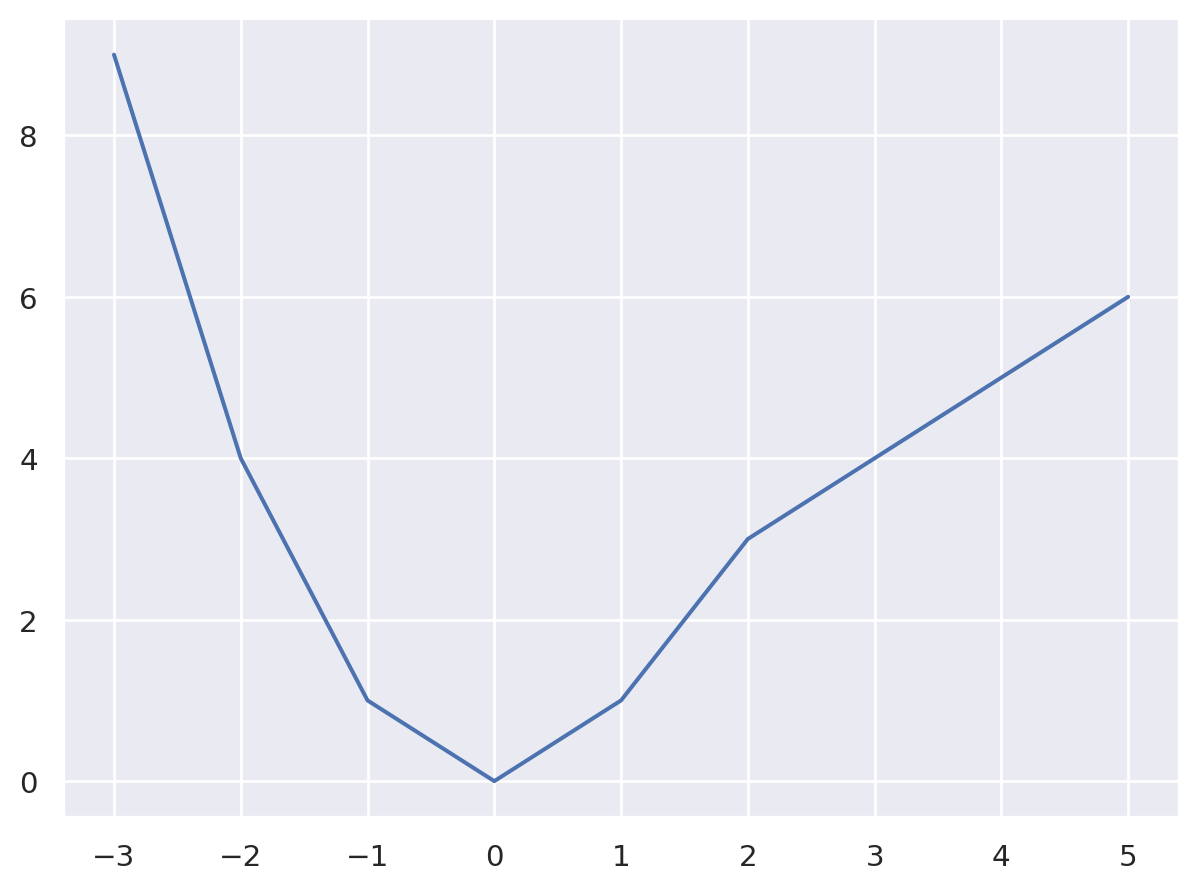

In [ ]:
x = np.arange(-3, 6)
(
    so.Plot(x = x, y = [f(xs) for xs in x])
    .add(so.Line())
)

**Ejemplo.** Queremos agregar "Super" adelante de todas las variables de Oferta.

Para listas por comprensión usamos la sintaxis

`[f(x) if CONDICION else g(x) for x in LISTA]`

Acá `f(x) if CONDICION else g(x)` es una función lambda.

In [ ]:
# Ejemplo. Qué hace el siguiente comando?
[x / 2 if (x % 2 == 0) else x for x in np.arange(1,10)]   # np.arange nos da todos los enteros desde 1 a 10 (exclusive)

[np.int64(1),
 np.float64(1.0),
 np.int64(3),
 np.float64(2.0),
 np.int64(5),
 np.float64(3.0),
 np.int64(7),
 np.float64(4.0),
 np.int64(9)]

**Nota:** Comparar con el if que habiamos usado antes en listas por comprensión, ¿cuál es la diferencia?

In [ ]:
macro.rename(columns = lambda col: 'Super'+col if col.startswith("Oferta") else col) #hacerlo con las variables !

,ano,pbi,SuperOfertaAgricultura,SuperOfertaMinas,SuperOfertaManufacturera,SuperOfertaElectricidad,SuperOfertaConstruccion,SuperOfertaComercio,SuperOfertaTransporte,SuperOfertaFinaciera,...,DemandaConsumoHogares,DemandaConsumoGobiertano,DemandaConstrucciones,DemandaMaterialNacional,DemandaMaterialImportada,DemandaMaquinariaNacional,DemandaMaquinariaImportaciones,DemandaExportaciones,DemandaImportaciones,DemandaGib
0,1950,142098481044,13696637358,1452011417,32304751942,198218385,5918090281,25281650565,7262970408,19550757718,...,104655579712,21706316451,20353627362,668586865,584400198,3119383475,863112352,10729585056,14039465296,142098481044
1,1951,147436076837,14629457210,1686941522,33149279696,212725994,6060937395,26260862055,7534071597,19902737804,...,110537717447,21767097618,21739314091,842740200,2532757698,3562534310,1292775007,8455493993,15744444593,147436076837
2,1952,140491256038,12545616104,1794762161,32522906863,227896262,5571363747,24417324287,7017131008,20598804008,...,105108053681,21455589059,19685428171,1119084065,1484421674,3440750327,1088415946,6224082425,11637586183,140491256038
3,1953,147324304004,16402296333,1925706862,32341045582,242404261,5546340195,24009746257,7210541490,20716225895,...,106402901621,20742065172,20237375978,1207890913,1459988875,3621895632,886926720,9619869463,9626750804,147324304004
4,1954,153315563451,16308747029,2037374129,34903529762,263839496,5308705373,25492912808,7558082163,21278479393,...,114392396415,21238933697,19372130307,1173451578,805900196,4121320340,783079947,10201623290,12506287869,153315563451
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61,2011,711876372894,51232247600,23624757639,132833552973,11137192032,22917469985,109669382185,52052730045,98166614131,...,501468174468,80184420870,66813943052,11899022232,7661349361,23759578339,41326728494,159841680179,190143785790,709846118754
62,2012,706420870168,44579958519,23338178766,128887568646,11655890977,22357980999,107013302114,52391956399,99767726112,...,499877233083,82549920556,64700327691,11937482081,5518154212,21650676546,35683290813,153186765485,181049138448,704517238544
63,2013,722040183987,49721752068,22404030031,130944551380,11717769879,22344881459,109388604371,53702369755,100256426891,...,516595596894,86152836238,64634666531,13783168151,7239125008,24156151830,33736431348,146449825751,186368215953,720649972746
64,2014,705611747648,51321551605,22736711813,124263314517,11939156363,21877578423,102335931469,54087653912,98874388852,...,496730426540,89033326375,63301703123,10305735713,5950583136,21378949359,32538397909,136756102482,165611660510,703337679146


**Ejercicio.**
Convertir todos los nombres de columnas de Oferta a mayúsculas.

In [ ]:
macro.rename(columns = lambda col: col.upper() if col.startswith("Oferta") else col)

,ano,pbi,OFERTAAGRICULTURA,OFERTAMINAS,OFERTAMANUFACTURERA,OFERTAELECTRICIDAD,OFERTACONSTRUCCION,OFERTACOMERCIO,OFERTATRANSPORTE,OFERTAFINACIERA,...,DemandaConsumoHogares,DemandaConsumoGobiertano,DemandaConstrucciones,DemandaMaterialNacional,DemandaMaterialImportada,DemandaMaquinariaNacional,DemandaMaquinariaImportaciones,DemandaExportaciones,DemandaImportaciones,DemandaGib
0,1950,142098481044,13696637358,1452011417,32304751942,198218385,5918090281,25281650565,7262970408,19550757718,...,104655579712,21706316451,20353627362,668586865,584400198,3119383475,863112352,10729585056,14039465296,142098481044
1,1951,147436076837,14629457210,1686941522,33149279696,212725994,6060937395,26260862055,7534071597,19902737804,...,110537717447,21767097618,21739314091,842740200,2532757698,3562534310,1292775007,8455493993,15744444593,147436076837
2,1952,140491256038,12545616104,1794762161,32522906863,227896262,5571363747,24417324287,7017131008,20598804008,...,105108053681,21455589059,19685428171,1119084065,1484421674,3440750327,1088415946,6224082425,11637586183,140491256038
3,1953,147324304004,16402296333,1925706862,32341045582,242404261,5546340195,24009746257,7210541490,20716225895,...,106402901621,20742065172,20237375978,1207890913,1459988875,3621895632,886926720,9619869463,9626750804,147324304004
4,1954,153315563451,16308747029,2037374129,34903529762,263839496,5308705373,25492912808,7558082163,21278479393,...,114392396415,21238933697,19372130307,1173451578,805900196,4121320340,783079947,10201623290,12506287869,153315563451
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61,2011,711876372894,51232247600,23624757639,132833552973,11137192032,22917469985,109669382185,52052730045,98166614131,...,501468174468,80184420870,66813943052,11899022232,7661349361,23759578339,41326728494,159841680179,190143785790,709846118754
62,2012,706420870168,44579958519,23338178766,128887568646,11655890977,22357980999,107013302114,52391956399,99767726112,...,499877233083,82549920556,64700327691,11937482081,5518154212,21650676546,35683290813,153186765485,181049138448,704517238544
63,2013,722040183987,49721752068,22404030031,130944551380,11717769879,22344881459,109388604371,53702369755,100256426891,...,516595596894,86152836238,64634666531,13783168151,7239125008,24156151830,33736431348,146449825751,186368215953,720649972746
64,2014,705611747648,51321551605,22736711813,124263314517,11939156363,21877578423,102335931469,54087653912,98874388852,...,496730426540,89033326375,63301703123,10305735713,5950583136,21378949359,32538397909,136756102482,165611660510,703337679146


**Ejercicio:** Como podemos combinar los dos "if"? Generar una lista de nombres de columnas que no tenga las variables de demanda y a las de oferta le agregamos Super al principio.

In [ ]:
["Super" + x if x.startswith("Oferta") else x for x in macro.columns if not x.startswith("Demanda")]

['ano',
 'pbi',
 'SuperOfertaAgricultura',
 'SuperOfertaMinas',
 'SuperOfertaManufacturera',
 'SuperOfertaElectricidad',
 'SuperOfertaConstruccion',
 'SuperOfertaComercio',
 'SuperOfertaTransporte',
 'SuperOfertaFinaciera',
 'SuperOfertaSociales',
 'SuperOfertaImpuestos']

**Ejercicio.** Por un error en el formato CSV, todos los nombres de columnas en el siguiente dataframe excepto "ano" tienen un espacio adelante. Generar un DataFrame macroClean con los nombres arreglados.
1. Realizarlo utilizando la función str.strip
2. Realizarlo utilizando c[1:] para eliminar el primer caracter en los casos que corresponda

In [ ]:
macroEspacio = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Lic_CsdeDatos/LaboDatos/OfertaYDemandaEspacio.csv")
macroEspacio.head()

,ano,pbi,OfertaAgricultura,OfertaMinas,OfertaManufacturera,OfertaElectricidad,OfertaConstruccion,OfertaComercio,OfertaTransporte,OfertaFinaciera,...,DemandaConsumoHogares,DemandaConsumoGobiertano,DemandaConstrucciones,DemandaMaterialNacional,DemandaMaterialImportada,DemandaMaquinariaNacional,DemandaMaquinariaImportaciones,DemandaExportaciones,DemandaImportaciones,DemandaGib
0,1950,142098481044,13696637358,1452011417,32304751942,198218385,5918090281,25281650565,7262970408,19550757718,...,104655579712,21706316451,20353627362,668586865,584400198,3119383475,863112352,10729585056,14039465296,142098481044
1,1951,147436076837,14629457210,1686941522,33149279696,212725994,6060937395,26260862055,7534071597,19902737804,...,110537717447,21767097618,21739314091,842740200,2532757698,3562534310,1292775007,8455493993,15744444593,147436076837
2,1952,140491256038,12545616104,1794762161,32522906863,227896262,5571363747,24417324287,7017131008,20598804008,...,105108053681,21455589059,19685428171,1119084065,1484421674,3440750327,1088415946,6224082425,11637586183,140491256038
3,1953,147324304004,16402296333,1925706862,32341045582,242404261,5546340195,24009746257,7210541490,20716225895,...,106402901621,20742065172,20237375978,1207890913,1459988875,3621895632,886926720,9619869463,9626750804,147324304004
4,1954,153315563451,16308747029,2037374129,34903529762,263839496,5308705373,25492912808,7558082163,21278479393,...,114392396415,21238933697,19372130307,1173451578,805900196,4121320340,783079947,10201623290,12506287869,153315563451


In [ ]:
macroEspacio.rename(columns = str.strip).columns

Index(['ano', 'pbi', 'OfertaAgricultura', 'OfertaMinas', 'OfertaManufacturera',
       'OfertaElectricidad', 'OfertaConstruccion', 'OfertaComercio',
       'OfertaTransporte', 'OfertaFinaciera', 'OfertaSociales',
       'OfertaImpuestos', 'DemandaConsumoHogares', 'DemandaConsumoGobiertano',
       'DemandaConstrucciones', 'DemandaMaterialNacional',
       'DemandaMaterialImportada', 'DemandaMaquinariaNacional',
       'DemandaMaquinariaImportaciones', 'DemandaExportaciones',
       'DemandaImportaciones', 'DemandaGib'],
      dtype='object')

In [ ]:
#macroEspacio.rename(columns = lambda c: c[1:] if c!= 'ano' else c).columns
macroEspacio.rename(columns = lambda c: c[1:] if c.startswith(" ") else c).columns

Index(['ano', 'pbi', 'OfertaAgricultura', 'OfertaMinas', 'OfertaManufacturera',
       'OfertaElectricidad', 'OfertaConstruccion', 'OfertaComercio',
       'OfertaTransporte', 'OfertaFinaciera', 'OfertaSociales',
       'OfertaImpuestos', 'DemandaConsumoHogares', 'DemandaConsumoGobiertano',
       'DemandaConstrucciones', 'DemandaMaterialNacional',
       'DemandaMaterialImportada', 'DemandaMaquinariaNacional',
       'DemandaMaquinariaImportaciones', 'DemandaExportaciones',
       'DemandaImportaciones', 'DemandaGib'],
      dtype='object')